In [1]:
# ==========================================
# 📊 HR DATA ANALYSIS SCRIPT (with Comments)
# ==========================================

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# ------------------------------------------
# 1️⃣ Load Dataset
# ------------------------------------------
# Replace 'employees.csv' with your actual file name
df = pd.read_csv('empolyees.csv')
df

,EmployeeID,EmployeeName,Salary,Position,State,DateOfBirth,Gender,MaritalStatus,HiringDate,EmploymentStatus,Department,RecruitmentSource,PerformanceScore,EngagementSurvey,EmployeeSatisfaction,Tenure
0,1,John Smith,62506,Production Technician I,MA,1983-07-10,M,Single,2011-07-05,Active,Production,LinkedIn,Exceeds,4,5,14.263014
1,2,Sarah Johnson,104437,Sr. DBA,MA,1975-05-05,M,Married,2015-03-30,Voluntarily Terminated,IT/IS,Indeed,Fully Meets,4,3,10.526027
2,3,Michael Williams,64955,Production Technician II,MA,1988-09-19,F,Married,2011-07-05,Voluntarily Terminated,Production,LinkedIn,Fully Meets,3,3,14.263014
3,4,Emily Brown,64991,Production Technician I,MA,1988-09-27,F,Married,2008-01-07,Active,Production,Indeed,Fully Meets,4,5,17.756164
4,5,David Jones,50825,Production Technician I,MA,1989-09-08,F,Divorced,2011-07-11,Voluntarily Terminated,Production,Google Search,Fully Meets,5,4,14.246575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,307,Nana Asare,65893,Production Technician II,MA,1985-05-11,M,Single,2014-07-07,Active,Production,LinkedIn,Fully Meets,4,4,11.254795
307,308,Yaa Yeboah,48513,Production Technician I,MA,1982-05-04,F,Single,2008-09-02,Voluntarily Terminated,Production,Google Search,PIP,3,2,17.101370
308,309,Kojo Ofori,220450,CIO,MA,1979-08-30,F,Single,2010-04-10,Active,IT/IS,Employee Referral,Exceeds,4,5,15.498630
309,310,Esi Amoako,89292,Data Analyst,MA,1979-02-24,F,Single,2015-03-30,Active,IT/IS,Employee Referral,Fully Meets,5,3,10.526027


In [6]:
# Display basic info about the dataset
print("🔹 Dataset Info:")
print(df.info())

🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   EmployeeID            311 non-null    int64  
 1   EmployeeName          311 non-null    object 
 2   Salary                311 non-null    int64  
 3   Position              311 non-null    object 
 4   State                 311 non-null    object 
 5   DateOfBirth           311 non-null    object 
 6   Gender                311 non-null    object 
 7   MaritalStatus         311 non-null    object 
 8   HiringDate            311 non-null    object 
 9   EmploymentStatus      311 non-null    object 
 10  Department            311 non-null    object 
 11  RecruitmentSource     311 non-null    object 
 12  PerformanceScore      311 non-null    object 
 13  EngagementSurvey      311 non-null    int64  
 14  EmployeeSatisfaction  311 non-null    int64  
 15  Tenure 

In [7]:
df["Tenure"] = df["Tenure"].astype(int)

In [9]:
# Display basic info about the dataset
print("🔹 Dataset Info:")
print(df.info())

🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EmployeeID            311 non-null    int64 
 1   EmployeeName          311 non-null    object
 2   Salary                311 non-null    int64 
 3   Position              311 non-null    object
 4   State                 311 non-null    object
 5   DateOfBirth           311 non-null    object
 6   Gender                311 non-null    object
 7   MaritalStatus         311 non-null    object
 8   HiringDate            311 non-null    object
 9   EmploymentStatus      311 non-null    object
 10  Department            311 non-null    object
 11  RecruitmentSource     311 non-null    object
 12  PerformanceScore      311 non-null    object
 13  EngagementSurvey      311 non-null    int64 
 14  EmployeeSatisfaction  311 non-null    int64 
 15  Tenure                31

In [10]:
# ------------------------------------------
# 2️⃣ Data Cleaning
# ------------------------------------------

# Convert date columns to datetime format for proper analysis
df['DateOfBirth'] = pd.to_datetime(df['DateOfBirth'], errors='coerce')
df['HiringDate'] = pd.to_datetime(df['HiringDate'], errors='coerce')

In [11]:
# Check for missing values
print("\n🔹 Missing Values:")
print(df.isnull().sum())


🔹 Missing Values:
EmployeeID              0
EmployeeName            0
Salary                  0
Position                0
State                   0
DateOfBirth             0
Gender                  0
MaritalStatus           0
HiringDate              0
EmploymentStatus        0
Department              0
RecruitmentSource       0
PerformanceScore        0
EngagementSurvey        0
EmployeeSatisfaction    0
Tenure                  0
dtype: int64


In [12]:
# ------------------------------------------
# 3️⃣ Employee Status Breakdown
# ------------------------------------------
# Count how many employees are Active, Terminated, etc.
status_counts = df['EmploymentStatus'].value_counts()
print("\n🔹 Employment Status Count:")
print(status_counts)


🔹 Employment Status Count:
EmploymentStatus
Active                    207
Voluntarily Terminated     88
Terminated for Cause       16
Name: count, dtype: int64


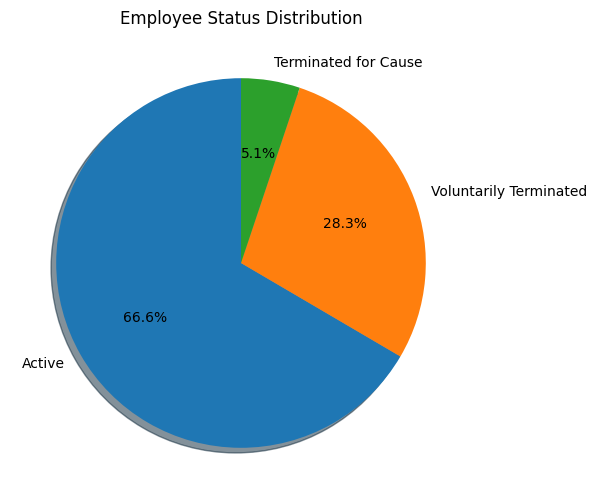

In [13]:
# Plot as a pie chart
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, shadow=True)
plt.title('Employee Status Distribution')
plt.show()

In [14]:
# ------------------------------------------
# 4️⃣ Average Salary by Department
# ------------------------------------------
avg_salary = df.groupby('Department')['Salary'].mean().sort_values(ascending=False)
print("\n🔹 Average Salary by Department:")
print(avg_salary)


🔹 Average Salary by Department:
Department
Executive Office     250000.000000
IT/IS                 97064.640000
Engineering           94989.454545
Admin Offices         71791.888889
Sales                 69061.258065
Production            59953.545455
Name: Salary, dtype: float64


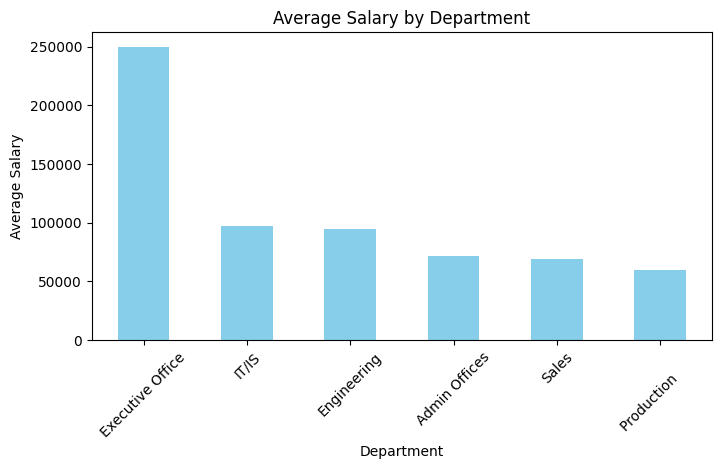

In [15]:
plt.figure(figsize=(8,4))
avg_salary.plot(kind='bar', color='skyblue')
plt.title('Average Salary by Department')
plt.ylabel('Average Salary')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.show()

In [16]:
# ------------------------------------------
# 5️⃣ Performance vs Employee Satisfaction
# ------------------------------------------
performance_satisfaction = df.groupby('PerformanceScore')['EmployeeSatisfaction'].mean()
print("\n🔹 Avg Satisfaction by Performance Rating:")
print(performance_satisfaction)


🔹 Avg Satisfaction by Performance Rating:
PerformanceScore
Exceeds              4.108108
Fully Meets          3.950617
Needs Improvement    3.611111
PIP                  2.538462
Name: EmployeeSatisfaction, dtype: float64


C:\Users\pdmah\AppData\Local\Temp\ipykernel_29296\3721900378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='PerformanceScore', y='EmployeeSatisfaction', palette='Blues')


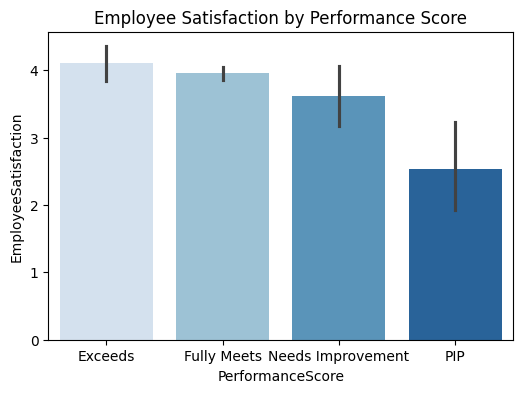

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='PerformanceScore', y='EmployeeSatisfaction', palette='Blues')
plt.title('Employee Satisfaction by Performance Score')
plt.show()


In [18]:
# ------------------------------------------
# 6️⃣ Recruitment Source Effectiveness
# ------------------------------------------
source_satisfaction = df.groupby('RecruitmentSource')['EmployeeSatisfaction'].mean().sort_values(ascending=False)
print("\n🔹 Average Satisfaction by Recruitment Source:")
print(source_satisfaction)


🔹 Average Satisfaction by Recruitment Source:
RecruitmentSource
On-line Web application    5.000000
Google Search              4.061224
Indeed                     3.942529
Employee Referral          3.935484
LinkedIn                   3.894737
Diversity Job Fair         3.793103
CareerBuilder              3.652174
Other                      3.500000
Website                    3.384615
Name: EmployeeSatisfaction, dtype: float64


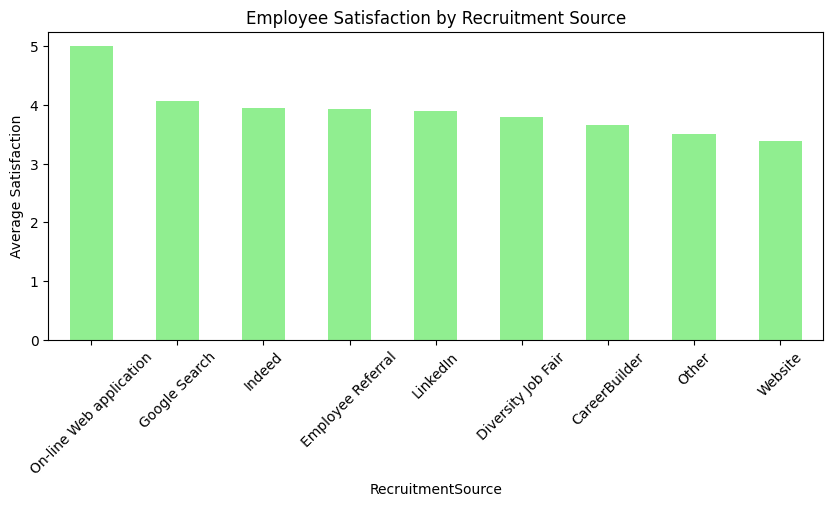

In [19]:
plt.figure(figsize=(10,4))
source_satisfaction.plot(kind='bar', color='lightgreen')
plt.title('Employee Satisfaction by Recruitment Source')
plt.ylabel('Average Satisfaction')
plt.xticks(rotation=45)
plt.show()

In [21]:
# ------------------------------------------
# 7️⃣ Tenure Analysis (Years Worked)
# ------------------------------------------
# Calculate employee tenure = today - hiring date
df['Tenure'] = (pd.Timestamp.today() - df['HiringDate']).dt.days / 365

# Average tenure by employment status
tenure_status = df.groupby('EmploymentStatus')['Tenure'].mean()
print("\n🔹 Average Tenure (Years) by Employment Status:")
print(tenure_status)


🔹 Average Tenure (Years) by Employment Status:
EmploymentStatus
Active                    12.118510
Terminated for Cause      12.538527
Voluntarily Terminated    14.005666
Name: Tenure, dtype: float64


C:\Users\pdmah\AppData\Local\Temp\ipykernel_29296\3200093012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_status.index, y=tenure_status.values, palette='Oranges')


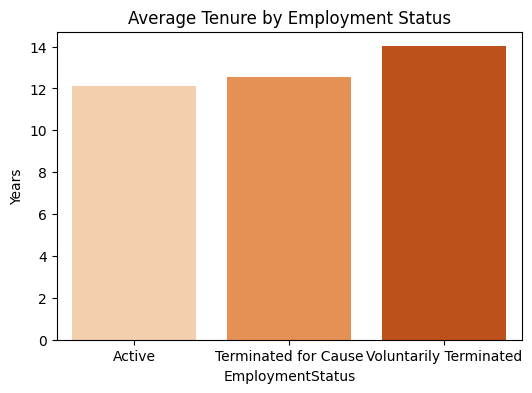

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(x=tenure_status.index, y=tenure_status.values, palette='Oranges')
plt.title('Average Tenure by Employment Status')
plt.ylabel('Years')
plt.show()

C:\Users\pdmah\AppData\Local\Temp\ipykernel_29296\116021238.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='PerformanceScore', y='EngagementSurvey', palette='Purples')


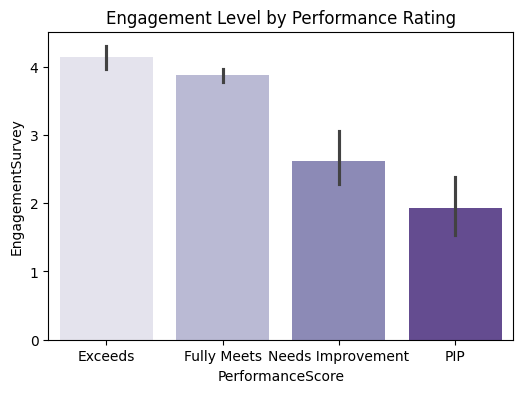

In [23]:
# ------------------------------------------
# 8️⃣ Engagement Survey vs Performance
# ------------------------------------------
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='PerformanceScore', y='EngagementSurvey', palette='Purples')
plt.title('Engagement Level by Performance Rating')
plt.show()

In [24]:
# ------------------------------------------
# 9️⃣ Bonus: Gender Distribution by Department
# ------------------------------------------
gender_dept = pd.crosstab(df['Department'], df['Gender'])
print("\n🔹 Gender Distribution by Department:")
print(gender_dept)


🔹 Gender Distribution by Department:
Gender               F  M 
Department                
Admin Offices        6   3
Engineering          6   5
Executive Office     1   0
IT/IS               22  28
Production         126  83
Sales               15  16


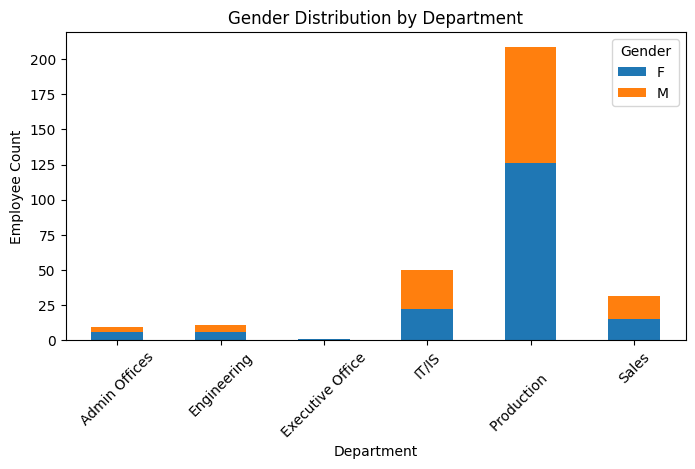

In [25]:
gender_dept.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title('Gender Distribution by Department')
plt.ylabel('Employee Count')
plt.xticks(rotation=45)
plt.show()

In [26]:
# ------------------------------------------
# 🏁 DONE!
# ------------------------------------------
print("\n✅ HR Analytics Completed Successfully!")


✅ HR Analytics Completed Successfully!


In [27]:
df.to_csv("HR_PR.csv",index=False)